**Question 6**

In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,accuracy_score
import seaborn as sns
# from sklearn.decomposition import PCA
!pip install tsfel
import tsfel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import precision_score, f1_score

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.9 MB/s eta 0:00:00


In [ ]:
 drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
desired_directory = '/content/drive/MyDrive/uci'
os.chdir(desired_directory)
uci_dir = os.getcwd()
print("Present Working Directory:", uci_dir)

Present Working Directory: /content/drive/MyDrive/uci


In [ ]:
train_root_folder = '/content/drive/MyDrive/uci/Combined/Train'

# list to store dictionaries for each subject-activity combinations
dict_train_list=[]

# Iterating over the activity folders in the train root directory and generating paths for each activity
for activity_folder in os.listdir(train_root_folder):
    activity_path = os.path.join(train_root_folder, activity_folder)

    if os.path.isdir(activity_path):

        # Iterating over each subject in the activity folderand generating paths
        for subject_file in os.listdir(activity_path):
            subject_file_path = os.path.join(activity_path, subject_file)

            if os.path.isfile(subject_file_path):

                #Extracting csv data->dataframe , subjectnumber and activity name from file
                df = pd.read_csv(subject_file_path)
                subject_number = subject_file.split('.')[0]
                activity_name = activity_folder.split('Activity')[-1].strip()


               #Calculating total acceletation and creating a dictionary to store them
                for i in range(500):
                  total_acc = df['accx'][i]**2 + df['accy'][i]**2 + df['accz'][i]**2
                  temp_dict = {
                      'SubjectNumber': subject_number,
                      'total_acc': total_acc,
                      'ActivityName': activity_name
                  }

                  dict_train_list.append(temp_dict)


train_df = pd.DataFrame(dict_train_list)    # DataFrame from list of dictionaries for the Train set

# train_df
# 21*500*6 = 63000 rows
# subjects * total_acc * activities

In [ ]:
#Code to reshape the df_dict_list dataframe such that each subject-activity combination acceleration values in one row
train_df['count'] = train_df.groupby(['SubjectNumber', 'ActivityName']).cumcount()

# Pivot the DataFrame wrt SubjectNumber and ActivityName
reshaped_train_df = train_df.pivot(index=['SubjectNumber', 'ActivityName'], columns='count', values='total_acc')

# Re-naming the columns accordingly
reshaped_train_df.columns = [f'total_acc_{i}' for i in range(1, reshaped_train_df.shape[1] + 1)]

reshaped_train_df.reset_index(inplace=True)   # Reset the df index

y_train = reshaped_train_df['ActivityName']
X_train = reshaped_train_df.drop(['ActivityName','SubjectNumber'], axis=1)

# X_train
# 126 rows ( 21 subjects * 6 activities) × 500 columns (total_acc)

In [ ]:
# y_pca_featured_train = reshaped_test_df['ActivityName']

In [ ]:
# Again fetching the Train data in the Desired format required for TSFEL (500,126)
train_root_folder = '/content/drive/MyDrive/uci/Combined/Train'

temp_dict_2={}


for activity_folder in os.listdir(train_root_folder):
    activity_path = os.path.join(train_root_folder, activity_folder)

    if os.path.isdir(activity_path):

        for subject_file in os.listdir(activity_path):
            subject_file_path = os.path.join(activity_path, subject_file)

            if os.path.isfile(subject_file_path):

                df = pd.read_csv(subject_file_path)
                subject_number = subject_file.split('.')[0]
                activity_number = activity_folder.split('Activity')[-1].strip()
                total_acc_list=[]           # list to store total_acceleration
                for i in range(500):
                  total_acc = df['accx'][i]**2 + df['accy'][i]**2 + df['accz'][i]**2
                  total_acc_list.append(total_acc)

                temp_dict_2['total_acc' + str(subject_number) + str(activity_number)] = total_acc_list   #dictionary to store the accel_list for each Subject-activity Combination

dff_train = pd.DataFrame(temp_dict_2)

# dff_train


In [ ]:
cfg = tsfel.get_features_by_domain("statistical")  #config file
features = tsfel.time_series_features_extractor(cfg, dff_train)
file_path = '/content/drive/MyDrive/features.csv'  # Change this to the desired file path

# Save DataFrame to CSV file
features.to_csv(file_path, index=False)  # Set index=False to exclude row indices from the CSV file

print(f"DataFrame has been saved to {file_path}")

*** Feature extraction started ***


<ipython-input-8-af5e83a32561>:2: UserWarning: Using default sampling frequency set in configuration file.
  features = tsfel.time_series_features_extractor(cfg, dff_train)



*** Feature extraction finished ***
DataFrame has been saved to /content/drive/MyDrive/features.csv


Extracting Features

In [ ]:

result = [
    'total_accSubject_11LAYING_Absolute energy',
    'total_accSubject_11LAYING_Average power',
    'total_accSubject_11LAYING_ECDF Percentile Count_0',
    'total_accSubject_11LAYING_ECDF Percentile Count_1',
    'total_accSubject_11LAYING_ECDF Percentile_0',
    'total_accSubject_11LAYING_ECDF Percentile_1',
    'total_accSubject_11LAYING_ECDF_0',
    'total_accSubject_11LAYING_ECDF_1',
    'total_accSubject_11LAYING_ECDF_2',
    'total_accSubject_11LAYING_ECDF_3',
    'total_accSubject_11LAYING_ECDF_4',
    'total_accSubject_11LAYING_ECDF_5',
    'total_accSubject_11LAYING_ECDF_6',
    'total_accSubject_11LAYING_ECDF_7',
    'total_accSubject_11LAYING_ECDF_8',
    'total_accSubject_11LAYING_ECDF_9',
    'total_accSubject_11LAYING_Entropy',
    'total_accSubject_11LAYING_Histogram_0',
    'total_accSubject_11LAYING_Histogram_1',
    'total_accSubject_11LAYING_Histogram_2',
    'total_accSubject_11LAYING_Histogram_3',
    'total_accSubject_11LAYING_Histogram_4',
    'total_accSubject_11LAYING_Histogram_5',
    'total_accSubject_11LAYING_Histogram_6',
    'total_accSubject_11LAYING_Histogram_7',
    'total_accSubject_11LAYING_Histogram_8',
    'total_accSubject_11LAYING_Histogram_9',
    'total_accSubject_11LAYING_Interquartile range',
    'total_accSubject_11LAYING_Kurtosis',
    'total_accSubject_11LAYING_Max',
    'total_accSubject_11LAYING_Mean',
    'total_accSubject_11LAYING_Mean absolute deviation',
    'total_accSubject_11LAYING_Median',
    'total_accSubject_11LAYING_Median absolute deviation',
    'total_accSubject_11LAYING_Min',
    'total_accSubject_11LAYING_Peak to peak distance',
    'total_accSubject_11LAYING_Root mean square',
    'total_accSubject_11LAYING_Skewness',
    'total_accSubject_11LAYING_Standard deviation',
    'total_accSubject_11LAYING_Variance'
]

feature_names = [part.split('LAYING_')[1].split(',')[0] for part in result]

print("Feature Names:")
print(feature_names)


Feature Names:
['Absolute energy', 'Average power', 'ECDF Percentile Count_0', 'ECDF Percentile Count_1', 'ECDF Percentile_0', 'ECDF Percentile_1', 'ECDF_0', 'ECDF_1', 'ECDF_2', 'ECDF_3', 'ECDF_4', 'ECDF_5', 'ECDF_6', 'ECDF_7', 'ECDF_8', 'ECDF_9', 'Entropy', 'Histogram_0', 'Histogram_1', 'Histogram_2', 'Histogram_3', 'Histogram_4', 'Histogram_5', 'Histogram_6', 'Histogram_7', 'Histogram_8', 'Histogram_9', 'Interquartile range', 'Kurtosis', 'Max', 'Mean', 'Mean absolute deviation', 'Median', 'Median absolute deviation', 'Min', 'Peak to peak distance', 'Root mean square', 'Skewness', 'Standard deviation', 'Variance']


In [ ]:
#since TSFEL returns Flattened dataframe, reshaping it to the required format(126,40)
tsfel_features_train = pd.DataFrame(features.values.reshape(126, 40), columns=range(1, 41))
# tsfel_features_train

In [ ]:
test_root_folder = '/content/drive/MyDrive/uci/Combined/Test'

# list to store dictionaries for each subject-activity combinations
dict_test_list=[]


for activity_folder in os.listdir(test_root_folder):
    activity_path = os.path.join(test_root_folder, activity_folder)

    if os.path.isdir(activity_path):

        for subject_file in os.listdir(activity_path):
            subject_file_path = os.path.join(activity_path, subject_file)

            if os.path.isfile(subject_file_path):

                df = pd.read_csv(subject_file_path)
                subject_number = subject_file.split('.')[0]
                activity_name = activity_folder.split('Activity')[-1].strip()


                for i in range(500):
                  total_acc = df['accx'][i]**2 + df['accy'][i]**2 + df['accz'][i]**2
                  temp_dict = {
                      'SubjectNumber': subject_number,
                      'total_acc': total_acc,
                      'ActivityName': activity_name
                  }
                  dict_test_list.append(temp_dict)


test_df = pd.DataFrame(dict_test_list)    # DataFrame from list of dictionaries for the Test set

# test_df
# 9*500*6 = 27000 rows
# subjects * total_acc * activities

In [ ]:
#Reshaping the df_dict_list dataframe such that each subject-activity combination acceleration values in one row
test_df['count'] = test_df.groupby(['SubjectNumber', 'ActivityName']).cumcount()

# Pivot the DataFrame wrt SubjectNumber and ActivityName
reshaped_test_df = test_df.pivot(index=['SubjectNumber', 'ActivityName'], columns='count', values='total_acc')

# Re-naming the columns
reshaped_test_df.columns = [f'total_acc_{i}' for i in range(1, reshaped_test_df.shape[1] + 1)]

reshaped_test_df.reset_index(inplace=True)   # Reset the df index

y_test = reshaped_test_df['ActivityName']
X_test = reshaped_test_df.drop(['ActivityName','SubjectNumber'], axis=1)

# X_test
# 54 rows (9 subjects* 6 activities) × 500 columns (total_acc)

Restructuring test data for TSFEL features

In [ ]:
# Again fetching the Test data in the Desired format required for TSFEL (500,126)
train_root_folder = '/content/drive/MyDrive/uci/Combined/Test'

temp_dict_test_2={}


for activity_folder in os.listdir(train_root_folder):
    activity_path = os.path.join(train_root_folder, activity_folder)

    if os.path.isdir(activity_path):

        for subject_file in os.listdir(activity_path):
            subject_file_path = os.path.join(activity_path, subject_file)

            if os.path.isfile(subject_file_path):

                df = pd.read_csv(subject_file_path)
                subject_number = subject_file.split('.')[0]
                activity_number = activity_folder.split('Activity')[-1].strip()
                total_acc_list=[]           # list to store total_acceleration
                for i in range(500):
                  total_acc = df['accx'][i]**2 + df['accy'][i]**2 + df['accz'][i]**2
                  total_acc_list.append(total_acc)

                temp_dict_test_2['total_acc' + str(subject_number) + str(activity_number)] = total_acc_list   #dictionary to store the accel_list for each Subject-activity Combination

dff_test = pd.DataFrame(temp_dict_test_2)    # dataframe with X_test data in required TSFEL format

dff_test


,total_accSubject_2WALKING,total_accSubject_4WALKING,total_accSubject_9WALKING,total_accSubject_10WALKING,total_accSubject_12WALKING,total_accSubject_13WALKING,total_accSubject_18WALKING,total_accSubject_20WALKING,total_accSubject_24WALKING,total_accSubject_4WALKING_UPSTAIRS,...,total_accSubject_24STANDING,total_accSubject_2LAYING,total_accSubject_4LAYING,total_accSubject_9LAYING,total_accSubject_10LAYING,total_accSubject_12LAYING,total_accSubject_13LAYING,total_accSubject_18LAYING,total_accSubject_20LAYING,total_accSubject_24LAYING
0,1.400242,1.715764,0.746680,0.725681,0.815687,0.731021,1.319072,0.574593,0.719149,0.445798,...,1.060202,1.019674,1.004123,0.991090,0.993788,0.923752,0.984591,1.038394,1.023349,1.044336
1,1.225756,1.501327,0.919438,0.591848,0.762340,0.945699,1.107530,0.609471,0.682259,0.501367,...,1.069088,1.003766,0.956493,0.987183,1.055319,0.962927,0.987984,1.035366,1.031253,1.033078
2,0.889694,1.535026,1.244351,0.559941,0.731789,1.089487,1.020312,0.692498,0.678885,0.510779,...,1.067454,1.000309,0.964615,1.033963,1.060211,1.017675,0.987486,1.036025,1.045090,1.027540
3,0.700821,1.580195,1.678832,0.580247,0.698925,1.068659,0.861052,0.872101,0.729966,0.549073,...,1.061965,1.008703,1.006322,1.058950,1.031627,1.057185,0.991153,1.035969,1.069506,1.027858
4,0.632164,1.587878,1.764755,0.613303,0.684802,1.033844,0.769464,1.044103,0.759323,0.708210,...,1.049681,1.010195,1.091522,1.013131,0.987709,1.041162,0.992533,1.041620,1.074795,1.023566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.911414,1.255192,1.230811,1.888273,0.584754,1.413436,1.784399,1.596596,1.369441,1.329446,...,1.051834,1.004442,0.995009,1.011373,0.999591,0.995799,0.996780,1.016172,1.028839,1.014532
496,0.966363,1.417635,1.037385,1.626153,0.288180,1.372016,1.715242,2.026975,1.433000,1.273147,...,1.051263,1.006752,0.992662,1.007129,0.999327,0.992677,0.996390,1.020141,1.040475,1.012077
497,1.083021,1.309269,0.798699,1.367669,0.644357,1.487429,1.442220,2.269695,1.347814,1.346403,...,1.054220,1.003935,0.988104,0.991313,1.000890,0.987368,0.996495,1.023006,1.052314,1.014254
498,1.150862,1.286748,0.678831,1.003176,0.983558,1.539651,1.024512,2.141566,0.986926,1.283411,...,1.055110,1.000992,0.992555,0.974911,1.002759,0.987749,1.001875,1.024464,1.049424,1.017823


In [ ]:
cfg = tsfel.get_features_by_domain("statistical")
features_test = tsfel.time_series_features_extractor(cfg, dff_test)
features_test
print(cfg)

*** Feature extraction started ***


<ipython-input-14-df82bf67d5c5>:2: UserWarning: Using default sampling frequency set in configuration file.
  features_test = tsfel.time_series_features_extractor(cfg, dff_test)



*** Feature extraction finished ***
{'statistical': {'Absolute energy': {'complexity': 'log', 'description': 'Computes the absolute energy of the signal.', 'function': 'tsfel.abs_energy', 'parameters': '', 'n_features': 1, 'use': 'yes', 'tag': 'audio'}, 'Average power': {'complexity': 'constant', 'description': 'Computes the average power of the signal.', 'function': 'tsfel.average_power', 'parameters': {'fs': 100}, 'n_features': 1, 'use': 'yes', 'tag': 'audio'}, 'ECDF': {'complexity': 'log', 'description': 'Computes the values of ECDF (empirical cumulative distribution function) along the time axis.', 'function': 'tsfel.ecdf', 'parameters': {'d': 10}, 'n_features': 'd', 'use': 'yes'}, 'ECDF Percentile': {'complexity': 'log', 'description': 'Determines the percentile value of the ECDF.', 'function': 'tsfel.ecdf_percentile', 'parameters': {'percentile': '[0.2, 0.8]'}, 'n_features': 'percentile', 'use': 'yes'}, 'ECDF Percentile Count': {'complexity': 'log', 'description': 'Determines th

In [ ]:
#since TSFEL returns Flattened dataframe, reshaping it to the required format(54,40)
tsfel_features_test = pd.DataFrame(features_test.values.reshape(54, 40), columns=range(1, 41))
tsfel_features_test

,1,2,3,4,5,6,7,8,9,10,...,31,32,33,34,35,36,37,38,39,40
0,506.181368,101.439152,100.000000,400.000000,1.001344,1.010999,0.002000,0.004000,0.006,0.008,...,1.006111,0.006128,1.006435,0.003969,0.951910,0.113718,1.006162,-0.098731,0.010131,0.000103
1,491.471794,98.491341,100.000000,400.000000,0.987519,0.995452,0.002000,0.004000,0.006,0.008,...,0.991423,0.003879,0.991346,0.003116,0.976035,0.031502,0.991435,0.099820,0.004980,0.000025
2,573.170900,114.863908,100.000000,400.000000,1.060781,1.080182,0.002000,0.004000,0.006,0.008,...,1.070362,0.014390,1.069879,0.007322,0.929026,0.370914,1.070674,1.324910,0.025843,0.000668
3,875.448732,175.440628,1399.854363,280.531937,100.000000,400.000000,0.426290,2.303278,0.002,0.004,...,0.150356,4.670315,1.295506,0.868598,0.861950,0.483125,0.074781,4.595535,1.673233,1.086656
4,1.058949,1.121372,100.000000,400.000000,0.629622,1.595577,0.002000,0.004000,0.006,0.008,...,1.178576,0.468671,1.064409,0.381968,0.288271,2.933517,1.323215,1.084562,0.601544,1008.949654
5,202.194319,100.000000,400.000000,0.566055,1.807621,0.002000,0.004000,0.006000,0.008,0.010,...,0.604648,0.997991,0.451542,0.102077,3.731391,1.420528,1.039158,0.753130,0.567205,0.361856
6,492.475103,98.692405,100.000000,400.000000,0.981748,1.003033,0.002000,0.004000,0.006,0.008,...,0.992293,0.011871,0.992322,0.007720,0.922622,0.140062,0.992447,0.016230,0.017445,0.000304
7,515.872074,103.381177,100.000000,400.000000,1.010601,1.020921,0.002000,0.004000,0.006,0.008,...,1.015721,0.005415,1.016115,0.004029,0.972478,0.069196,1.015748,-0.521586,0.007369,0.000054
8,568.380466,113.903901,100.000000,400.000000,1.061642,1.070896,0.002000,0.004000,0.006,0.008,...,1.066161,0.005281,1.066587,0.003860,1.023771,0.087626,1.066190,-0.278814,0.007785,0.000061
9,901.928804,180.747255,1005.507439,201.504497,100.000000,400.000000,0.598753,1.695616,0.002,0.004,...,2.296190,4.471713,1.174381,0.600988,0.878085,0.293081,0.314074,4.157639,1.418103,1.659235


In [ ]:
y_train = reshaped_train_df['ActivityName']

Accuracy: 0.8333333333333334
Precision: 0.8511904761904763
F-Score: 0.8378851540616247


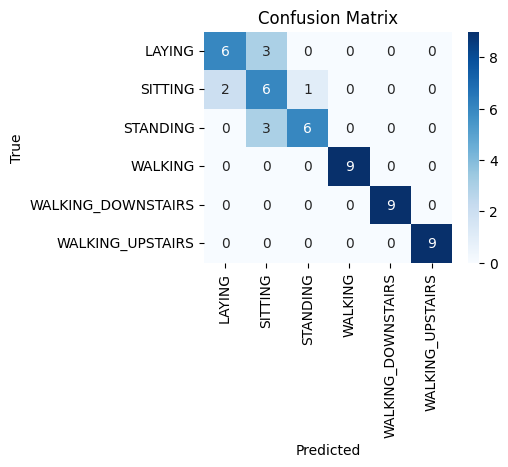

In [ ]:
classifier = DecisionTreeClassifier(random_state=42)  #initalizing the Decision Tree Classifier Model from sklearn
classifier.fit(tsfel_features_train,y_train)    #Training the Model
Y_pred_DT = classifier.predict(tsfel_features_test)

accuracy = accuracy_score(y_test, Y_pred_DT)
precision=precision_score(y_test,Y_pred_DT,average='macro')
f_score=f1_score(y_test, Y_pred_DT,average='macro')
print("Accuracy:", accuracy)
print("Precision:",precision)
print("F-Score:",f_score)
# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, Y_pred_DT)

# Plot the confusion matrix
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classifier.classes_, yticklabels=classifier.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


**Random Forest Classifier**

Accuracy: 0.9074074074074074
Precision: 0.9106481481481481
F-Score: 0.9082100676527921


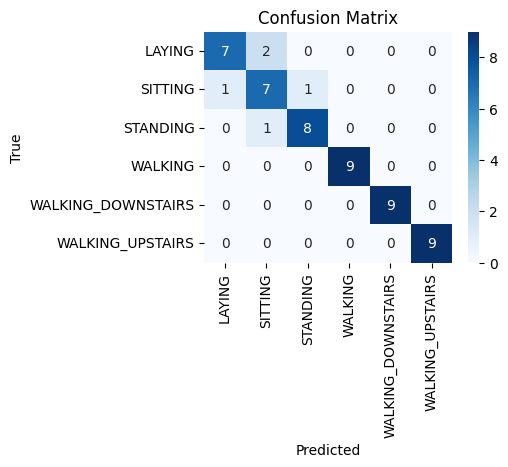

In [ ]:
RF_classifier=RandomForestClassifier(random_state=42)
RF_classifier.fit(tsfel_features_train,y_train)
Y_pred_RF = RF_classifier.predict(tsfel_features_test)
accuracy = accuracy_score(y_test, Y_pred_RF)
precision=precision_score(y_test,Y_pred_RF,average='macro')
f_score=f1_score(y_test, Y_pred_RF,average='macro')
print("Accuracy:", accuracy)
print("Precision:",precision)
print("F-Score:",f_score)

# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, Y_pred_RF)

# Plot the confusion matrix
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classifier.classes_, yticklabels=classifier.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


**Linear Regression**

Labelling Data

In [ ]:
y_test

0                 LAYING
1                SITTING
2               STANDING
3                WALKING
4     WALKING_DOWNSTAIRS
5       WALKING_UPSTAIRS
6                 LAYING
7                SITTING
8               STANDING
9                WALKING
10    WALKING_DOWNSTAIRS
11      WALKING_UPSTAIRS
12                LAYING
13               SITTING
14              STANDING
15               WALKING
16    WALKING_DOWNSTAIRS
17      WALKING_UPSTAIRS
18                LAYING
19               SITTING
20              STANDING
21               WALKING
22    WALKING_DOWNSTAIRS
23      WALKING_UPSTAIRS
24                LAYING
25               SITTING
26              STANDING
27               WALKING
28    WALKING_DOWNSTAIRS
29      WALKING_UPSTAIRS
30                LAYING
31               SITTING
32              STANDING
33               WALKING
34    WALKING_DOWNSTAIRS
35      WALKING_UPSTAIRS
36                LAYING
37               SITTING
38              STANDING
39               WALKING


In [ ]:
# Creating a dictionary to map activities to labels
activity_labels = {}
counter = 1     #labels starts from 1

# Looping through both DataFrames to find unique activities and assign a numerical label to it
for activity in y_test.unique():
    if activity not in activity_labels:
      activity_labels[activity] = counter
      counter += 1

# Adding a new column with numerical labels to both y_train and y_test
y_train['y_label_int'] = y_train.map(activity_labels)
y_test['y_label_int'] = y_test.map(activity_labels)

print(activity_labels)

{'LAYING': 1, 'SITTING': 2, 'STANDING': 3, 'WALKING': 4, 'WALKING_DOWNSTAIRS': 5, 'WALKING_UPSTAIRS': 6}


<ipython-input-20-9750bf7f1f99>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_train['y_label_int'] = y_train.map(activity_labels)
<ipython-input-20-9750bf7f1f99>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test['y_label_int'] = y_test.map(activity_labels)


In [ ]:
print("y_train:")
print(y_train)
print("\ny_test:")
print(y_test)

y_train:
0                                                         LAYING
1                                                        SITTING
2                                                       STANDING
3                                                        WALKING
4                                             WALKING_DOWNSTAIRS
                                     ...                        
122                                                     STANDING
123                                                      WALKING
124                                           WALKING_DOWNSTAIRS
125                                             WALKING_UPSTAIRS
y_label_int    0      1
1      2
2      3
3      4
4      5
 ...
Name: ActivityName, Length: 127, dtype: object

y_test:
0                                                         LAYING
1                                                        SITTING
2                                                       STANDING
3                        

In [ ]:

print("y_train:")
print(y_train['y_label_int'])
print("\ny_test:")
print(y_test['y_label_int'])

y_train:
0      1
1      2
2      3
3      4
4      5
      ..
121    2
122    3
123    4
124    5
125    6
Name: ActivityName, Length: 126, dtype: int64

y_test:
0     1
1     2
2     3
3     4
4     5
5     6
6     1
7     2
8     3
9     4
10    5
11    6
12    1
13    2
14    3
15    4
16    5
17    6
18    1
19    2
20    3
21    4
22    5
23    6
24    1
25    2
26    3
27    4
28    5
29    6
30    1
31    2
32    3
33    4
34    5
35    6
36    1
37    2
38    3
39    4
40    5
41    6
42    1
43    2
44    3
45    4
46    5
47    6
48    1
49    2
50    3
51    4
52    5
53    6
Name: ActivityName, dtype: int64


Training and testing the Model

In [ ]:
LR_Model=LinearRegression()
LR_Model.fit(tsfel_features_train, y_train['y_label_int'])
Y_pred_LR = LR_Model.predict(tsfel_features_test)

Y_pred_LR

array([1.38998625, 1.16281274, 2.84636172, 3.98068459, 4.17954299,
       6.48590411, 1.16524535, 1.54980833, 2.67833498, 3.68647705,
       5.94808316, 6.24104498, 1.19957918, 1.95177527, 2.93191139,
       4.69828008, 5.66477648, 5.95854299, 1.8073202 , 1.85084953,
       2.62120008, 4.58755824, 4.9023255 , 5.89069339, 2.20325788,
       2.17656658, 2.59051088, 4.1683582 , 4.52014608, 7.10312754,
       1.70473207, 2.11590841, 2.63405946, 3.66963398, 4.85985369,
       6.09894215, 1.44353098, 2.54873765, 3.11993085, 4.10890377,
       5.04639713, 6.4905045 , 1.35129046, 1.6690598 , 2.50222394,
       4.16459537, 5.13880387, 5.66601048, 1.19201332, 2.30636283,
       2.42506052, 4.05470948, 5.1455117 , 5.98202261])

In [ ]:
label_range = np.arange(1, 7)

Y_pred_LR_rounded = np.clip(np.round(Y_pred_LR), label_range[0], label_range[-1]).astype(int)

print(Y_pred_LR_rounded)


[1 1 3 4 4 6 1 2 3 4 6 6 1 2 3 5 6 6 2 2 3 5 5 6 2 2 3 4 5 6 2 2 3 4 5 6 1
 3 3 4 5 6 1 2 3 4 5 6 1 2 2 4 5 6]


In [ ]:

label_map = { 6:'WALKING_UPSTAIRS', 5:'WALKING_DOWNSTAIRS' ,4:'WALKING',  3:'STANDING', 2:'SITTING',  1:'LAYING'}
Y_pred_LR_df = pd.DataFrame(Y_pred_LR_rounded, columns=['predicted values'])

Y_pred_activities = Y_pred_LR_df.applymap(lambda x: label_map.get(x)) #mapping the labels

print(Y_pred_activities)

      predicted values
0               LAYING
1               LAYING
2             STANDING
3              WALKING
4              WALKING
5     WALKING_UPSTAIRS
6               LAYING
7              SITTING
8             STANDING
9              WALKING
10    WALKING_UPSTAIRS
11    WALKING_UPSTAIRS
12              LAYING
13             SITTING
14            STANDING
15  WALKING_DOWNSTAIRS
16    WALKING_UPSTAIRS
17    WALKING_UPSTAIRS
18             SITTING
19             SITTING
20            STANDING
21  WALKING_DOWNSTAIRS
22  WALKING_DOWNSTAIRS
23    WALKING_UPSTAIRS
24             SITTING
25             SITTING
26            STANDING
27             WALKING
28  WALKING_DOWNSTAIRS
29    WALKING_UPSTAIRS
30             SITTING
31             SITTING
32            STANDING
33             WALKING
34  WALKING_DOWNSTAIRS
35    WALKING_UPSTAIRS
36              LAYING
37            STANDING
38            STANDING
39             WALKING
40  WALKING_DOWNSTAIRS
41    WALKING_UPSTAIRS
42         

In [ ]:
 y_test = y_test.drop('y_label_int', axis=0)

In [ ]:
y_test

0                 LAYING
1                SITTING
2               STANDING
3                WALKING
4     WALKING_DOWNSTAIRS
5       WALKING_UPSTAIRS
6                 LAYING
7                SITTING
8               STANDING
9                WALKING
10    WALKING_DOWNSTAIRS
11      WALKING_UPSTAIRS
12                LAYING
13               SITTING
14              STANDING
15               WALKING
16    WALKING_DOWNSTAIRS
17      WALKING_UPSTAIRS
18                LAYING
19               SITTING
20              STANDING
21               WALKING
22    WALKING_DOWNSTAIRS
23      WALKING_UPSTAIRS
24                LAYING
25               SITTING
26              STANDING
27               WALKING
28    WALKING_DOWNSTAIRS
29      WALKING_UPSTAIRS
30                LAYING
31               SITTING
32              STANDING
33               WALKING
34    WALKING_DOWNSTAIRS
35      WALKING_UPSTAIRS
36                LAYING
37               SITTING
38              STANDING
39               WALKING


In [ ]:
print(Y_pred_activities)

      predicted values
0               LAYING
1               LAYING
2             STANDING
3              WALKING
4              WALKING
5     WALKING_UPSTAIRS
6               LAYING
7              SITTING
8             STANDING
9              WALKING
10    WALKING_UPSTAIRS
11    WALKING_UPSTAIRS
12              LAYING
13             SITTING
14            STANDING
15  WALKING_DOWNSTAIRS
16    WALKING_UPSTAIRS
17    WALKING_UPSTAIRS
18             SITTING
19             SITTING
20            STANDING
21  WALKING_DOWNSTAIRS
22  WALKING_DOWNSTAIRS
23    WALKING_UPSTAIRS
24             SITTING
25             SITTING
26            STANDING
27             WALKING
28  WALKING_DOWNSTAIRS
29    WALKING_UPSTAIRS
30             SITTING
31             SITTING
32            STANDING
33             WALKING
34  WALKING_DOWNSTAIRS
35    WALKING_UPSTAIRS
36              LAYING
37            STANDING
38            STANDING
39             WALKING
40  WALKING_DOWNSTAIRS
41    WALKING_UPSTAIRS
42         

Accuracy: 0.7962962962962963
Precision: 0.8042628667628667
F-Score: 0.7947167755991287


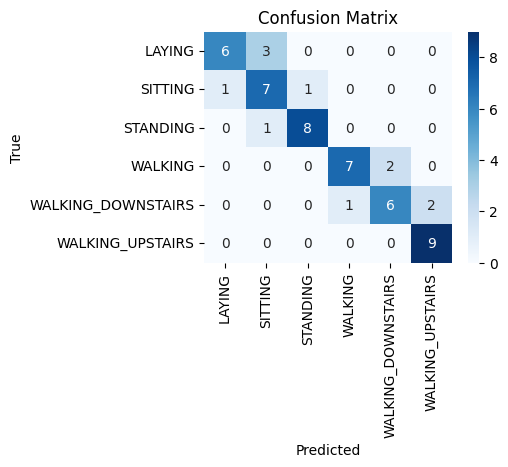

In [ ]:
accuracy = accuracy_score(y_test, Y_pred_activities)
precision=precision_score(y_test,Y_pred_activities,average='macro')
f_score=f1_score(y_test, Y_pred_activities,average='macro')

print("Accuracy:", accuracy)
print("Precision:",precision)
print("F-Score:",f_score)

# Creating confusion matrix
conf_matrix = confusion_matrix(y_test, Y_pred_activities)

# Plotting the confusion matrix
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classifier.classes_, yticklabels=classifier.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

**Question: Is the usage of linear regression for classification justified? Why or why not?**




No , use of Linear Regression is not justified for Classification Problems due to following reasons:


*   Real Outputs: Since Output of Linear Regression is continous (which can also exceed the classification labels) whereas for classification we need discrete outputs.Therefore conversion of Continous Output to discrete class can decrease accuracy of prediction.

* Interpretability: Coefficients of Linear Regression are more interpretable in case of Regression problem but in Case of Classification problem interpreting the coefficients can be difficuilt.
For example , if in regression problem coefficient of a feature is high that means that with change in that feature value will significant change the predicted y but making such interpretation is difficult for Classification task where outputs are Labels.


*   Poor Model Performance: We observed decrease in performace metrics while using Linear Regression for CLassification Task as compared to other Models. Linear Regression assumes that the input  features and output labels are linear,which may not be true for classification problems.

**Question 7**

Weights for Linear Regression

In [ ]:
weights = LR_Model.coef_
weights=np.abs(weights)
weights

array([1.08534514e-02, 4.89299933e-02, 1.46966052e+00, 7.30968912e+00,
       3.11408236e+00, 9.90077456e+00, 4.28390107e-01, 9.73640504e-01,
       1.47344358e+01, 1.47344357e+01, 1.47344352e+01, 1.47344352e+01,
       1.47344351e+01, 1.47344352e+01, 1.47344352e+01, 1.19570553e+02,
       3.45747700e+03, 7.26002320e+01, 3.63001160e+03, 9.87246840e-10,
       9.12048215e-11, 1.33638136e-01, 4.10144350e-02, 1.50498398e-02,
       3.34047587e-03, 1.35261495e-02, 3.61760233e-04, 3.74241838e-04,
       3.65003449e-03, 4.73780022e-01, 1.70360298e-01, 1.20274943e-01,
       8.23782124e+00, 6.90789657e+00, 5.01178888e-01, 2.33210731e-01,
       2.17770801e+00, 3.86539036e-03, 2.79666906e+00, 6.85148965e-04])

In [ ]:
intercept=LR_Model.intercept_
print(intercept)

-705.7229999599424


In [ ]:
weights.sum()

7427.8908521237545

In [ ]:
weights_scaled =np.divide(weights, weights.sum())
print(weights_scaled)
print(weights_scaled.sum())

[1.46117541e-06 6.58733337e-06 1.97857043e-04 9.84086770e-04
 4.19241804e-04 1.33291869e-03 5.76731828e-05 1.31079000e-04
 1.98366347e-03 1.98366347e-03 1.98366340e-03 1.98366339e-03
 1.98366338e-03 1.98366339e-03 1.98366340e-03 1.60975107e-02
 4.65472240e-01 9.77400360e-03 4.88700180e-01 1.32910790e-13
 1.22786970e-14 1.79913974e-05 5.52167982e-06 2.02612560e-06
 4.49720645e-07 1.82099465e-06 4.87029548e-08 5.03833248e-08
 4.91395817e-07 6.37839235e-05 2.29352182e-05 1.61923412e-05
 1.10903908e-03 9.29994357e-04 6.74725703e-05 3.13966287e-05
 2.93179861e-04 5.20388686e-07 3.76509175e-04 9.22400421e-08]
0.9999999999999998


**Random Forest Feature Importance**

In [ ]:
feature_importance=RF_classifier.feature_importances_
print(feature_importance)
print(feature_importance.sum())
print(len(feature_importance))

[0.07250912 0.05540251 0.01646724 0.01426074 0.07088072 0.05830899
 0.0062133  0.01762944 0.01766314 0.02542691 0.01095631 0.02060354
 0.02007843 0.02110023 0.01254719 0.01829057 0.01997487 0.01370611
 0.01150901 0.         0.         0.         0.         0.00840209
 0.00790178 0.00840387 0.01894365 0.03842115 0.01518266 0.03444774
 0.04881166 0.03279596 0.05628634 0.03665041 0.03750401 0.02102459
 0.05372128 0.00894105 0.02505135 0.04398204]
1.0
40


**Bar Graph Plot for Weights and Feature Importances**

In [ ]:
feature_importance

array([0.07250912, 0.05540251, 0.01646724, 0.01426074, 0.07088072,
       0.05830899, 0.0062133 , 0.01762944, 0.01766314, 0.02542691,
       0.01095631, 0.02060354, 0.02007843, 0.02110023, 0.01254719,
       0.01829057, 0.01997487, 0.01370611, 0.01150901, 0.        ,
       0.        , 0.        , 0.        , 0.00840209, 0.00790178,
       0.00840387, 0.01894365, 0.03842115, 0.01518266, 0.03444774,
       0.04881166, 0.03279596, 0.05628634, 0.03665041, 0.03750401,
       0.02102459, 0.05372128, 0.00894105, 0.02505135, 0.04398204])

In [ ]:
weights_scaled

array([1.46117541e-06, 6.58733337e-06, 1.97857043e-04, 9.84086770e-04,
       4.19241804e-04, 1.33291869e-03, 5.76731828e-05, 1.31079000e-04,
       1.98366347e-03, 1.98366347e-03, 1.98366340e-03, 1.98366339e-03,
       1.98366338e-03, 1.98366339e-03, 1.98366340e-03, 1.60975107e-02,
       4.65472240e-01, 9.77400360e-03, 4.88700180e-01, 1.32910790e-13,
       1.22786970e-14, 1.79913974e-05, 5.52167982e-06, 2.02612560e-06,
       4.49720645e-07, 1.82099465e-06, 4.87029548e-08, 5.03833248e-08,
       4.91395817e-07, 6.37839235e-05, 2.29352182e-05, 1.61923412e-05,
       1.10903908e-03, 9.29994357e-04, 6.74725703e-05, 3.13966287e-05,
       2.93179861e-04, 5.20388686e-07, 3.76509175e-04, 9.22400421e-08])

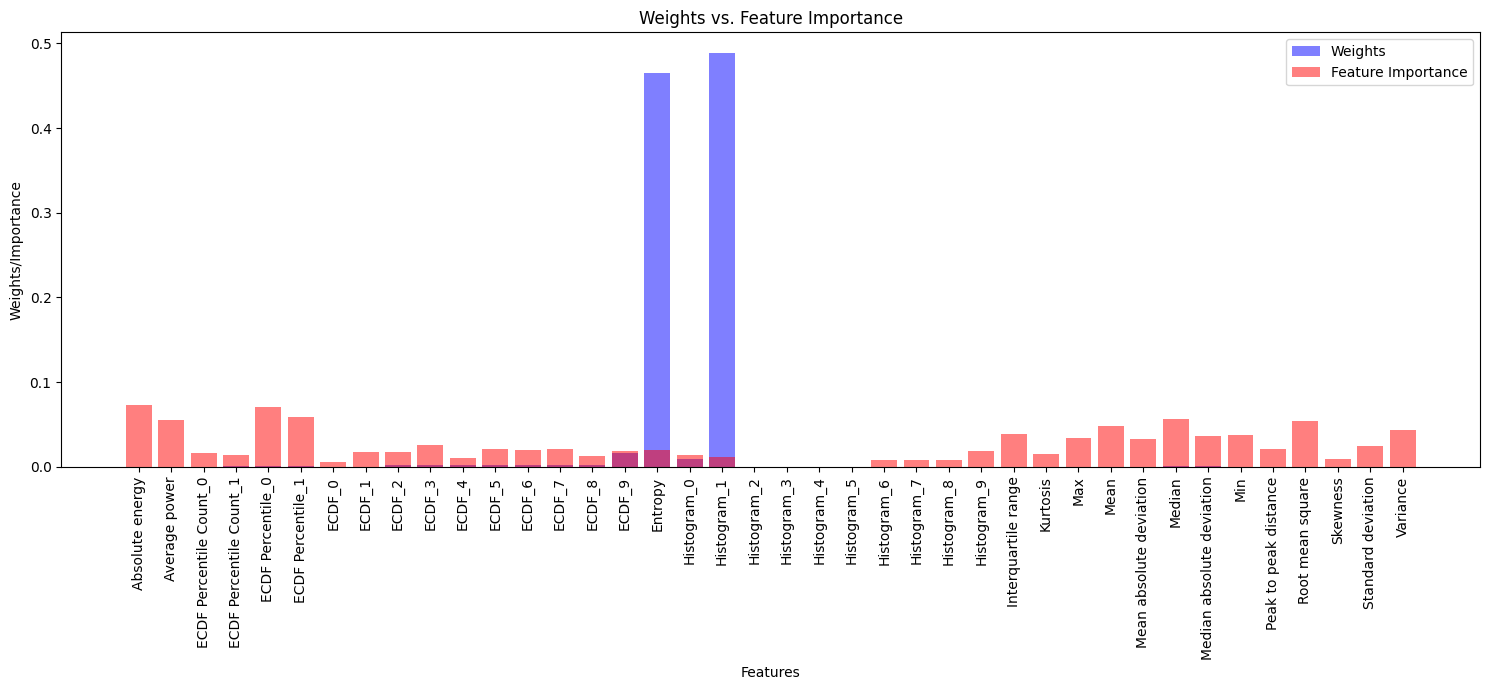

In [ ]:

fig, ax = plt.subplots(figsize=(15, 7))  # Adjust the figsize as needed

ax.bar(feature_names, weights_scaled, color='b', alpha=0.5, label='Weights')

ax.bar(feature_names, feature_importance, color='r', alpha=0.5, label='Feature Importance')

ax.set_xlabel('Features')
ax.set_ylabel('Weights/Importance')
ax.set_title('Weights vs. Feature Importance')
ax.legend()

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
weights_scaled_df=pd.DataFrame(feature_names,columns=["Features"])
weights_scaled_df['Weights']=weights_scaled
#print(weights_scaled_df)

In [ ]:
sorted_scaled_weights = weights_scaled_df.sort_values(by='Weights', ascending=False)
sorted_scaled_weights=sorted_scaled_weights.reset_index(drop=True)   #Reset index
print('Top 10 Important Features from LR Model\n')
print(sorted_scaled_weights[:10]['Features'])

Top 10 Important Features from LR Model

0    Histogram_1
1        Entropy
2         ECDF_9
3    Histogram_0
4         ECDF_2
5         ECDF_3
6         ECDF_8
7         ECDF_4
8         ECDF_5
9         ECDF_7
Name: Features, dtype: object


In [ ]:
feature_importance_df=pd.DataFrame(feature_names,columns=["Features"])
feature_importance_df['Feature Importance']=feature_importance
#print(feature_importance_df)

In [ ]:
sorted_feature_importance = feature_importance_df.sort_values(by='Feature Importance', ascending=False)
sorted_feature_importance=sorted_feature_importance.reset_index(drop=True) #Reset index
print('Top 10 Important Features from RF Model\n')
print(sorted_feature_importance[:10]['Features'])

Top 10 Important Features from RF Model

0        Absolute energy
1      ECDF Percentile_0
2      ECDF Percentile_1
3                 Median
4          Average power
5       Root mean square
6                   Mean
7               Variance
8    Interquartile range
9                    Min
Name: Features, dtype: object


Question: What do you infer from the results?

We can observe from the Bar Graph Plot that there is a mismatch between the Feature Weights of Linear Regression Model and Feature Importance of Random Forest Model. The Linear Regression Model  Weights are only concentrated to two features (Entropy and Histogram_1) and  for other features the weights are very less , which means that LR model is making decision based on only two features while in case of Random Forest, Feature importance is well distributed over different features which means Random Forest makes decision considering most of the features.

Since we are also getting lower performance for Linear Regression as compared to Random Forest , We can conclude that the model is making wrong assumptions about the data and there exists non-linear patterns in the data which Linear Regression Model is not able to capture.